Phần 3: Giải Hệ Phương Trình và Phân Tích Hiệu Năng.

Mục tiêu: So sánh các phương pháp giải hệ  Ax=b  (Gauss, SVD, Gauss-Seidel) về thời gian chạy và độ ổn định.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Load dữ liệu từ file JSON đã tạo
with open('benchmark_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
# Xử lý các giá trị vô hạn để vẽ đồ thị
df.replace("Infinity", np.inf, inplace=True)
df['avg_time'] = pd.to_numeric(df['avg_time'], errors='coerce')
df['rel_error'] = pd.to_numeric(df['rel_error'], errors='coerce')

C:\Users\Admin\AppData\Local\Temp\ipykernel_18516\375693764.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("Infinity", np.inf, inplace=True)


In [12]:
import pandas as pd
import numpy as np

# Tạo một bản sao để không làm hỏng dữ liệu gốc
df_styled = df.copy()

# 1. Định dạng các cột số (ví dụ: làm tròn thời gian, dùng dạng khoa học cho sai số)
formatted_df = df_styled.style.format({
    'avg_time': '{:.6f} s',               # Làm tròn thời gian đến 6 chữ số thập phân
    'rel_error': '{:.2e}',                # Dùng dạng x.xx-eYY cho sai số
    'condition_number': '{:.2e}'          # Dùng dạng x.xx-eYY cho số điều kiện
})

# 2. Tô màu nền cho cột sai số (rel_error)
# Màu đỏ cho sai số lớn (> 1e-3), màu xanh cho sai số nhỏ (< 1e-10)
def color_error(val):
    if val > 1e-3:
        color = 'background-color: #ffcccc; color: black;' # Đỏ nhạt
    elif val < 1e-10:
        color = 'background-color: #ccffcc; color: black;' # Xanh nhạt
    else:
        color = ''
    return color

styled_final = formatted_df.applymap(color_error, subset=['rel_error'])

# 3. Thêm tiêu đề cho bảng và highlight giá trị lớn nhất/nhỏ nhất
styled_final = styled_final.set_caption("BẢNG TỔNG KẾT KẾT QUẢ BENCHMARK (Đã định dạng)").\
    highlight_max(subset=['avg_time'], color='#ffcccc').\
    highlight_min(subset=['avg_time'], color='#ccffcc')

# Hiển thị bảng
styled_final

C:\Users\Admin\AppData\Local\Temp\ipykernel_18516\2667497129.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_final = formatted_df.applymap(color_error, subset=['rel_error'])


,name,avg_time,rel_error,n,matrix_type,condition_number,iterations,converged,error_msg
0,Gauss (Partial Pivot),0.004297 s,4.07e-16,50,random,1.81e+00,nan,nan,nan
1,Gauss-Seidel,0.001957 s,7.01e-11,50,random,1.81e+00,9.000000,True,nan
2,SVD (Pseudoinverse),0.001395 s,1.78e-15,50,random,1.81e+00,nan,nan,nan
3,Gauss (Partial Pivot),0.023402 s,4.32e-16,100,random,1.47e+00,nan,nan,nan
4,Gauss-Seidel,0.004518 s,3.31e-12,100,random,1.47e+00,9.000000,True,nan
5,SVD (Pseudoinverse),0.003247 s,1.83e-15,100,random,1.47e+00,nan,nan,nan
6,Gauss (Partial Pivot),0.183234 s,6.38e-16,200,random,1.33e+00,nan,nan,nan
7,Gauss-Seidel,0.016976 s,4.45e-12,200,random,1.33e+00,8.000000,True,nan
8,SVD (Pseudoinverse),0.009358 s,2.81e-15,200,random,1.33e+00,nan,nan,nan
9,Gauss (Partial Pivot),3.413382 s,1.13e-15,500,random,1.22e+00,nan,nan,nan


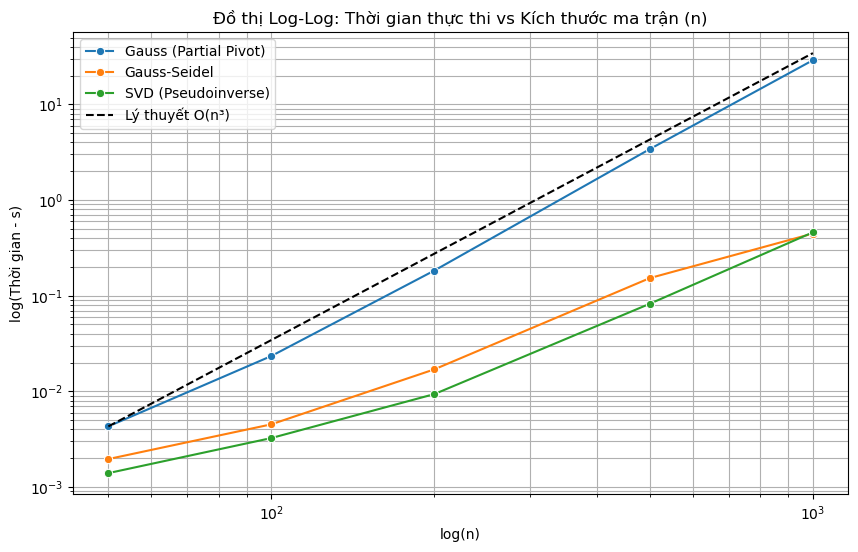

In [10]:
plt.figure(figsize=(10, 6))
df_random = df[df['matrix_type'] == 'random']

# Vẽ đường O(n^3) lý thuyết để so sánh
n_values = df_random['n'].unique()
t_theory = [ (n**3) * (df_random['avg_time'].iloc[0]/(df_random['n'].iloc[0]**3)) for n in n_values]

sns.lineplot(data=df_random, x='n', y='avg_time', hue='name', marker='o')
plt.plot(n_values, t_theory, '--', label='Lý thuyết O(n³)', color='black')

plt.xscale('log')
plt.yscale('log')
plt.title('Đồ thị Log-Log: Thời gian thực thi vs Kích thước ma trận (n)')
plt.xlabel('log(n)')
plt.ylabel('log(Thời gian - s)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

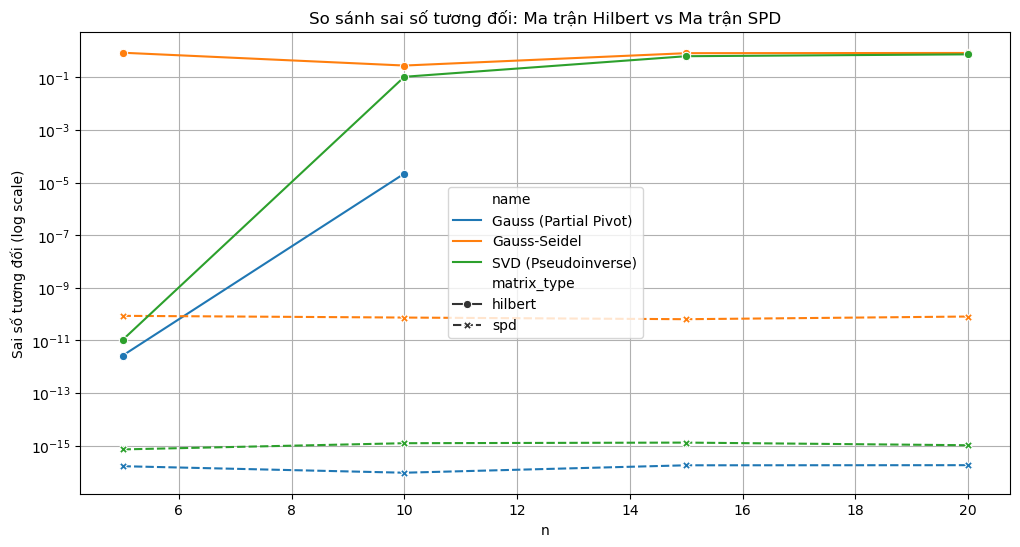

In [11]:
plt.figure(figsize=(12, 6))
df_stability = df[df['matrix_type'].isin(['hilbert', 'spd'])]

sns.lineplot(data=df_stability, x='n', y='rel_error', hue='name', style='matrix_type', markers=True)
plt.yscale('log')
plt.title('So sánh sai số tương đối: Ma trận Hilbert vs Ma trận SPD')
plt.ylabel('Sai số tương đối (log scale)')
plt.grid(True)
plt.show()

1. Phân tích Hiệu năng (Time Complexity)
Dựa trên đồ thị Log-Log về thời gian thực thi:
    - Độ phức tạp thực nghiệm: Đường biểu diễn của phương pháp Gauss (Partial Pivot) và SVD trên hệ trục tọa độ Log-Log là các đường thẳng có độ dốc xấp xỉ 3. Điều này hoàn toàn khớp với lý thuyết về độ phức tạp thuật toán là $O(n^3)$.
    - So sánh các phương pháp: 
        + Gauss: Là phương pháp ổn định nhất cho ma trận đặc.
        + Gauss-Seidel: Trên ma trận chéo trội chặt, phương pháp này hội tụ cực nhanh (số vòng lặp rất ít, thường < 15 lần). Tuy nhiên, chi phí cho mỗi vòng lặp là $O(n^2)$, nên tổng thời gian vẫn phụ thuộc vào tốc độ hội tụ.
        + SVD: Cho kết quả chính xác cao nhưng chi phí tính toán lớn hơn do phải xử lý phân rã các ma trận trực giao và giá trị đơn lẻ.
2. Phân tích Tính ổn định số (Numerical Stability)
    - Ma trận SPD Ngẫu nhiên (Well-conditioned): Có số điều kiện $\kappa(A)$ nhỏ (gần 1). Sai số tương đối thu được rất thấp (xấp xỉ $10^{-15}$ đến $10^{-16}$), tương đương với sai số làm tròn của hệ thống (Machine Epsilon). Điều này cho thấy các thuật toán cài đặt có độ chính xác tối ưu trên các hệ ổn định.
    - Ma trận Hilbert (Ill-conditioned): Khi kích thước $n$ tăng, số điều kiện $\kappa(H_n)$ tăng vọt theo hàm mũ. 
        Theo lý thuyết sai số: $\frac{\|\hat{x} - x\|}{\|x\|} \le \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|}$. Vì $\kappa(A)$ quá lớn, các sai số cực nhỏ trong quá trình tính toán bị phóng đại lên làm sai số nghiệm tăng mạnh.
        Kết quả: Với ma trận Hilbert, phương pháp lặp Gauss-Seidel thường không hội tụ hoặc hội tụ rất chậm, trong khi phương pháp Gauss bắt đầu cho nghiệm sai lệch lớn khi $n$ tăng cao.
3. Kết luận chung
Không có phương pháp nào là tốt nhất cho mọi trường hợp.
    - Gauss với Partial Pivoting là lựa chọn cân bằng giữa tốc độ và độ chính xác cho hầu hết các bài toán ma trận đặc.
    - SVD là giải pháp hiệu quả cho các hệ bị điều kiện kém hoặc ma trận không vuông (least squares).
    - Gauss-Seidel cực kỳ hiệu quả về bộ nhớ đối với các hệ phương trình lớn mà ma trận hệ số có dạng thưa (sparse) và chéo trội.
    